# 使用 scTour 进行轨迹推断

这里以胰腺内分泌发育数据为例，使用原始 UMI counts 演示 scTour 的 latent-time 学习流程，以及基于 neural ordinary differential equation 的轨迹建模方式。

## 方法背景

参考 [scTour 官方文档](https://sctour.readthedocs.io/) 和原始 [Genome Biology 论文](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-023-02988-9)，scTour 是一个深度学习框架，可以直接从 abundance matrix 中联合学习 latent representation、developmental pseudotime 和 vector field。

它的核心思路可以概括为：

- 先把细胞编码到能够表征发育结构的 latent space 中
- 在无需 spliced/unspliced counts 的前提下学习 pseudotime
- 用 neural ODE 风格的动力学模型描述连续的状态转变
- 利用学到的 latent dynamics 同时支持轨迹推断和细胞进展预测

因此，当我们希望使用神经网络式的 latent-time 模型，或者当前数据没有 RNA velocity 前处理输入时，scTour 会是一个很有吸引力的选择。

## 为什么这里使用胰腺数据？

胰腺内分泌发育具有紧凑的连续进展过程和清晰的中间 endocrine 状态，因此很适合观察 scTour 是否能够恢复合理的 latent-time 排序与发育方向。

## 数据预处理

这里我们以胰腺发育数据为例演示轨迹推断。

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata=ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=3000,)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

🔍 [2026-04-25 11:19:19] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.08s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.61 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.3058s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (4.57s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 4.5725s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


我们先查看各个主成分对总方差的贡献。这一步可以帮助判断后续构建细胞邻接关系时需要使用多少个 PC。实际分析中，通常只需要一个大致合理的 PC 数即可。

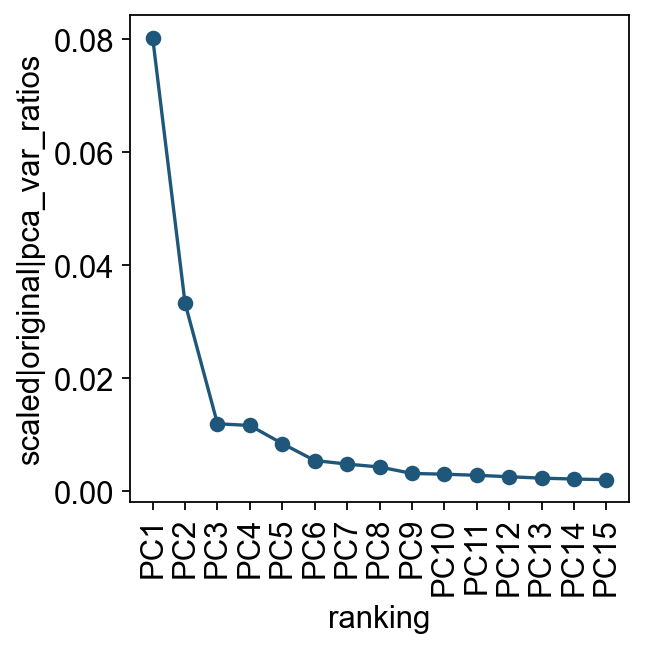

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


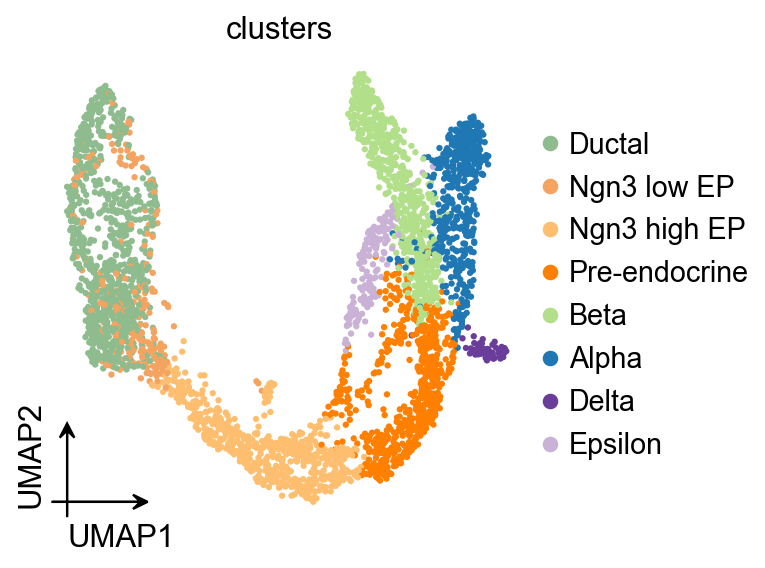

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## scTour

scTour 是一种用于解析单细胞组学数据中细胞动态过程的方法。

它把 developmental pseudotime、vector field 和 latent space 放在同一个框架中建模，从多个角度刻画发育过程。

接下来训练 scTour 模型。默认的 `loss_mode` 是 negative binomial conditioned likelihood (`nb`)，需要把原始 UMI counts 放在 AnnData 的 `.X` 中。默认情况下，当细胞数少于 10,000 时使用 90% 的细胞训练；当细胞数超过 10,000 时使用 20% 的细胞训练。用户也可以通过 `percent` 参数调整训练细胞比例，例如 `percent=0.6`。

In [6]:
adata.X=adata.layers['counts'].copy()
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

In [7]:
Traj=ov.single.TrajInfer(
    adata,basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50
)
Traj.inference(
    method='sctour',
    alpha_recon_lec=0.5,
    alpha_recon_lode=0.5
)

Running using CPU.


  0%|          | 0/400 [00:00<?, ?epoch/s]

Epoch 1:   0%|          | 0/400 [00:00<?, ?epoch/s]

Epoch 1:   0%|          | 1/400 [00:00<03:38,  1.82epoch/s, train_loss=2.29e+3, val_loss=2.22e+3]

Epoch 2:   0%|          | 1/400 [00:01<03:38,  1.82epoch/s, train_loss=2.29e+3, val_loss=2.22e+3]

...

Epoch 399: 100%|█████████▉| 398/400 [03:28<00:01,  1.89epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

Epoch 399: 100%|█████████▉| 399/400 [03:28<00:00,  1.92epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

Epoch 400: 100%|█████████▉| 399/400 [03:29<00:00,  1.92epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

Epoch 400: 100%|██████████| 400/400 [03:29<00:00,  1.95epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

Epoch 400: 100%|██████████| 400/400 [03:29<00:00,  1.91epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

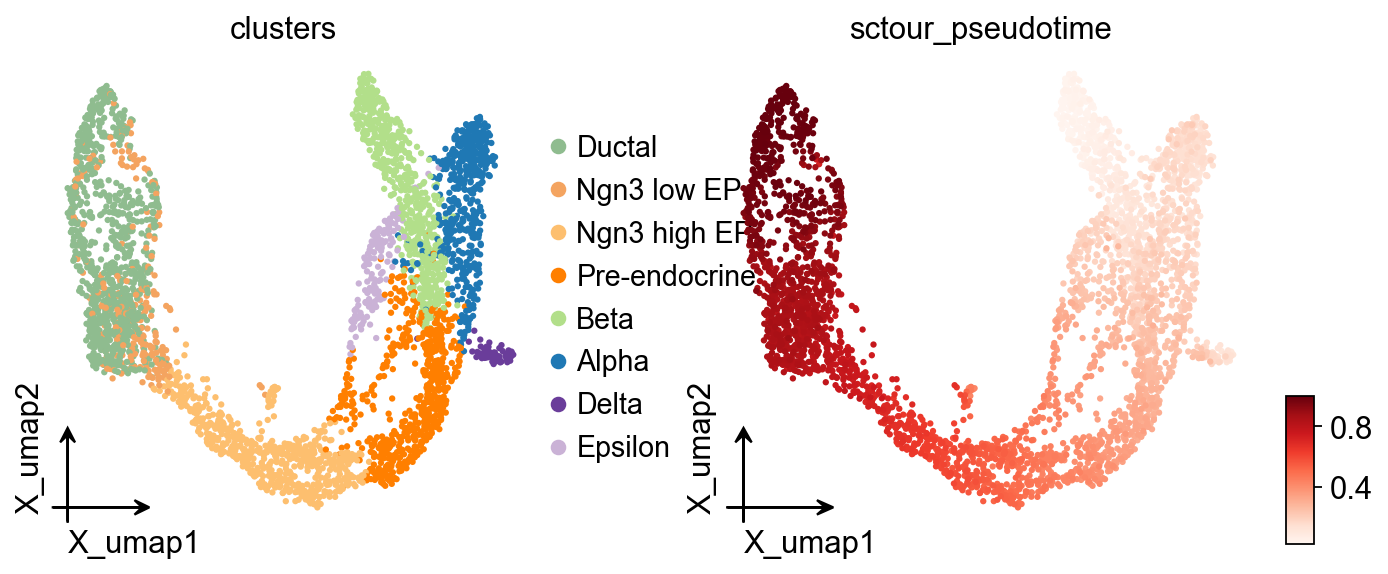

In [8]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color=['clusters','sctour_pseudotime'],
    frameon='small',
    cmap='Reds'
)

In [9]:
adata.obs['sctour_pseudotime']=1-adata.obs['sctour_pseudotime']

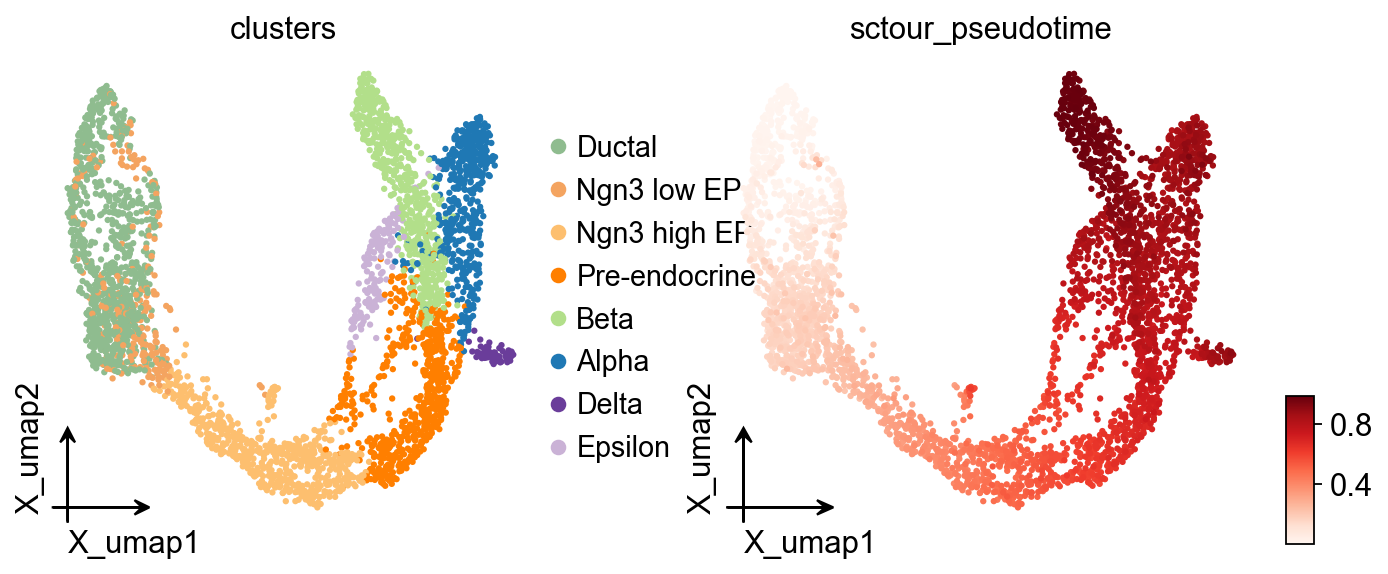

In [10]:
ov.pl.embedding(
    adata,basis='X_umap',
    color=['clusters','sctour_pseudotime'],
    frameon='small',
    cmap='Reds'
)

In [11]:
import os

os.makedirs('data', exist_ok=True)
adata.write('data/traj_tutorial.h5ad')

In [12]:
adata=ov.read('data/traj_tutorial.h5ad')
adata

AnnData object with n_obs × n_vars = 3696 × 3000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'n_genes_by_counts', 'total_counts', 'sctour_pseudotime'
    var: 'highly_variable_genes', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'REFERENCE_MANU', '_ov_provenance', 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'history_log', 'hvg', 'log1p', 'neighbors', 'pca', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'status', 'status_args'
    obsm: 'UMAP', 'X_TNODE', 'X_VF', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

## 分支感知的伪时间流图

`ov.pl.branch_streamplot` 只需要伪时间和细胞状态标签，因此也可以用于这个轨迹推断方法。图中 ribbon 的宽度表示某类细胞在伪时间上的富集位置，分叉的中心线则帮助观察不同 endocrine fate 在何处展开。


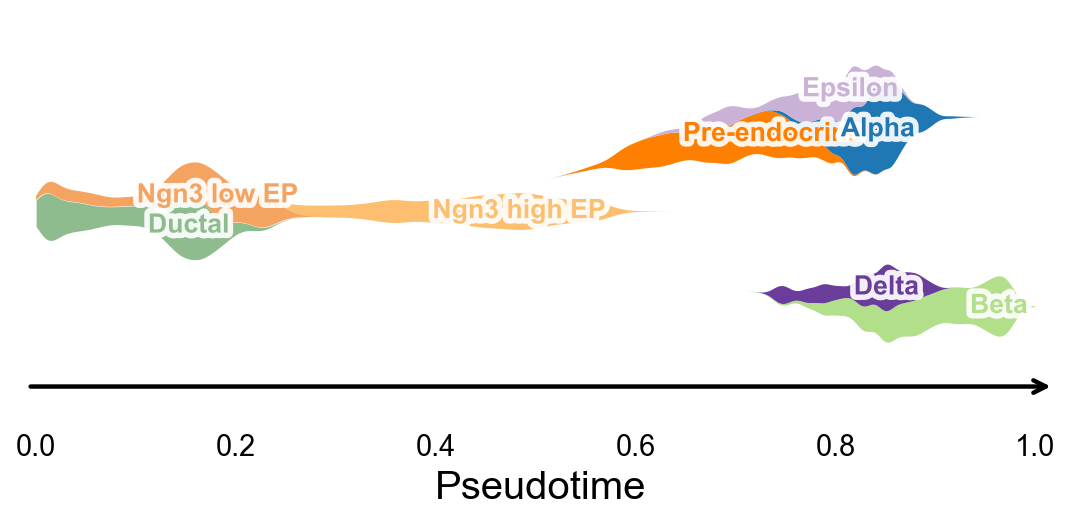

In [13]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='sctour_pseudotime',
    show=False,
)
plt.show()


## 使用 `dynamic_features` / `dynamic_trends` 分析 scTour 伪时间

同样的 GAM 趋势层也可以接到 `sctour_pseudotime` 上。这里先展示一张全局 marker 趋势图，并用 cluster 给原始散点着色；然后再比较晚期 Alpha / Beta 分支，展示分支相关的表达变化。

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sctour_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

sctour_dyn = ov.single.dynamic_features(
    adata,
    genes=sctour_genes,
    pseudotime='sctour_pseudotime',
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)


🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: sctour_pseudotime
   Stored raw obs keys: ['clusters']
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


### Single-line global trends

这张图为每个基因只拟合一条全局趋势线，同时用细胞注释给原始散点着色。它适合区分“整体伪时间表达趋势”和“哪些细胞状态贡献了这些散点”。




🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False
✅ Dynamic trend plotting completed!


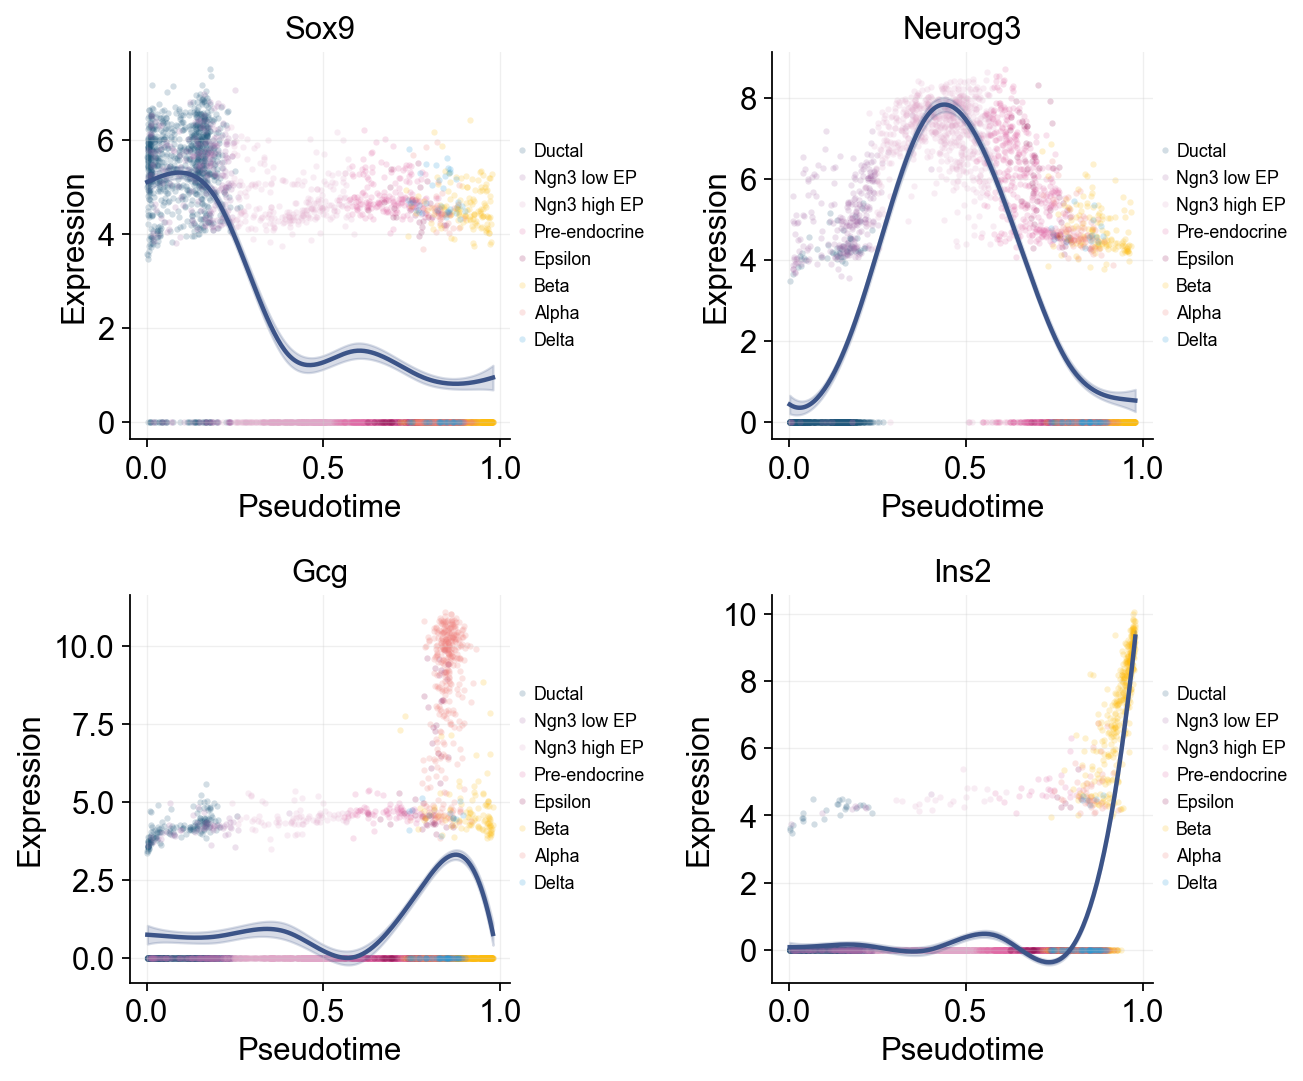

In [15]:
fig, _ = ov.pl.dynamic_trends(
    sctour_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
    ncols=2,
    return_fig=True,
)
display(fig)
plt.close(fig)


### 多标记基因趋势比较

这里把多个 marker 的拟合曲线叠加在同一伪时间坐标中，方便直接比较不同程序的启动和衰减顺序。



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False
✅ Dynamic trend plotting completed!


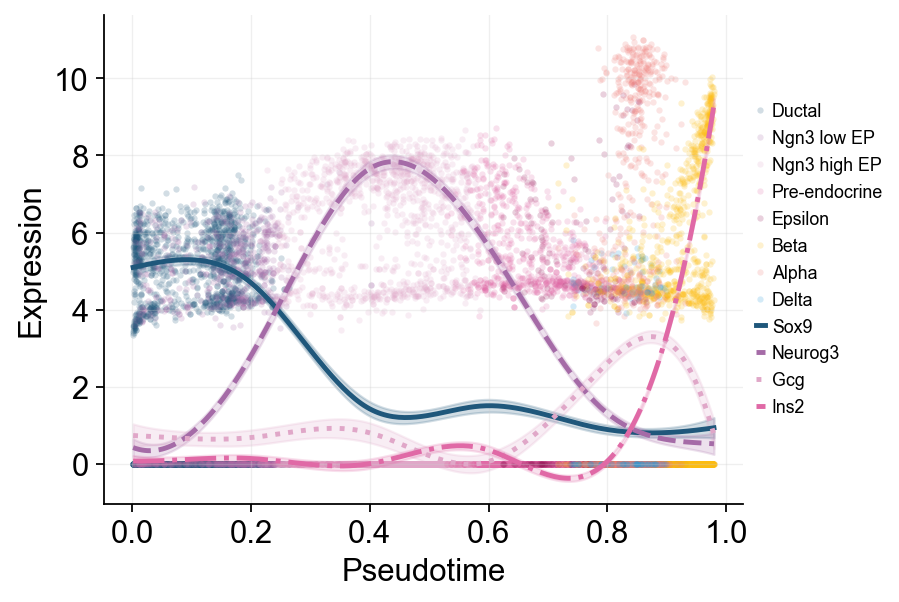

In [16]:
fig, _ = ov.pl.dynamic_trends(
    sctour_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    figsize=(7, 4),
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
    return_fig=True,
)
display(fig)
plt.close(fig)


In [17]:
branch_clusters = ['Alpha', 'Beta']
split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])

sctour_branch_dyn = ov.single.dynamic_features(
    adata,
    genes=['Gcg', 'Ins2', 'Pax4', 'Sox9'],
    pseudotime='sctour_pseudotime',
    groupby='clusters',
    groups=branch_clusters,
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
split_time = float(np.nanmedian(adata.obs.loc[split_mask, 'sctour_pseudotime'])) if split_mask.any() else float(np.nanmedian(adata.obs['sctour_pseudotime']))



🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: sctour_pseudotime
   Grouping: clusters
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 4288



🔍 Dynamic trend plotting:
   Features: 3 | Groups: 2
   compare_features=False | compare_groups=True
✅ Dynamic trend plotting completed!


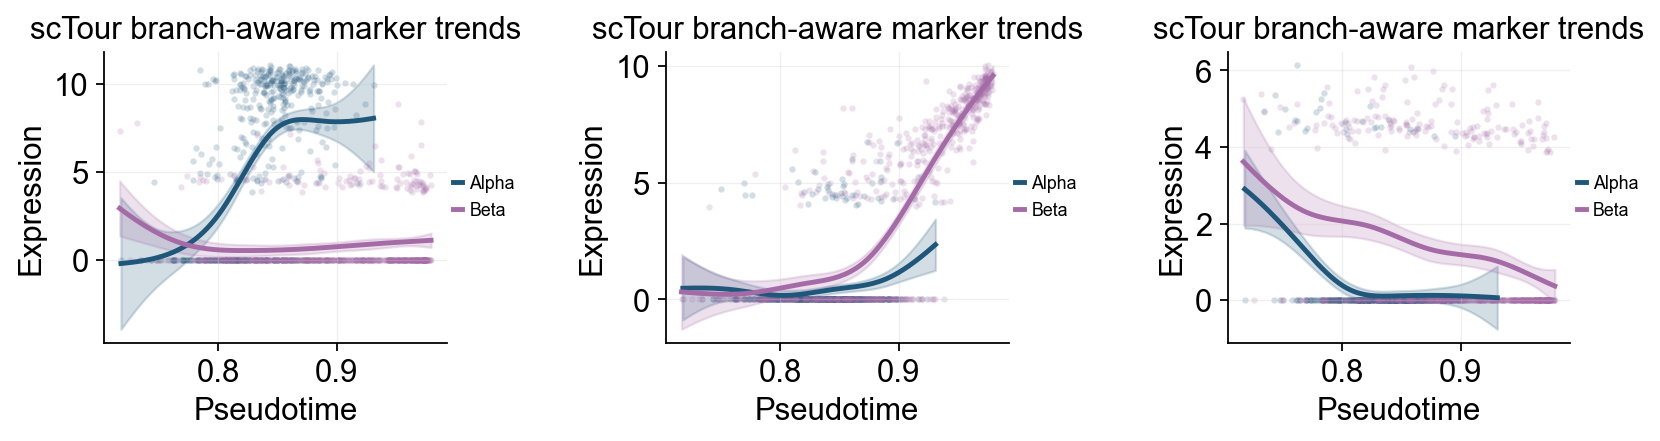

In [18]:
fig, _ = ov.pl.dynamic_trends(
    sctour_branch_dyn,
    genes=['Gcg', 'Ins2', 'Pax4'],
    compare_groups=True,
    split_time=split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(4.2, 3),
    ncols=3,
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='scTour branch-aware marker trends',
    return_fig=True,
)
display(fig)
plt.close(fig)


## 使用 `dynamic_heatmap` 概括 scTour 标记基因程序

`ov.pl.dynamic_heatmap` 可以把多组 marker program 压缩成一张按伪时间排序的热图，用来检查 progenitor、Alpha、Beta 和 Delta 程序是否沿 scTour 伪时间按预期顺序启动。



🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: sctour_pseudotime
   Cell annotation: clusters
   use_fitted=True | cell_bins=180 | cmap=RdBu_r



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 180 columns


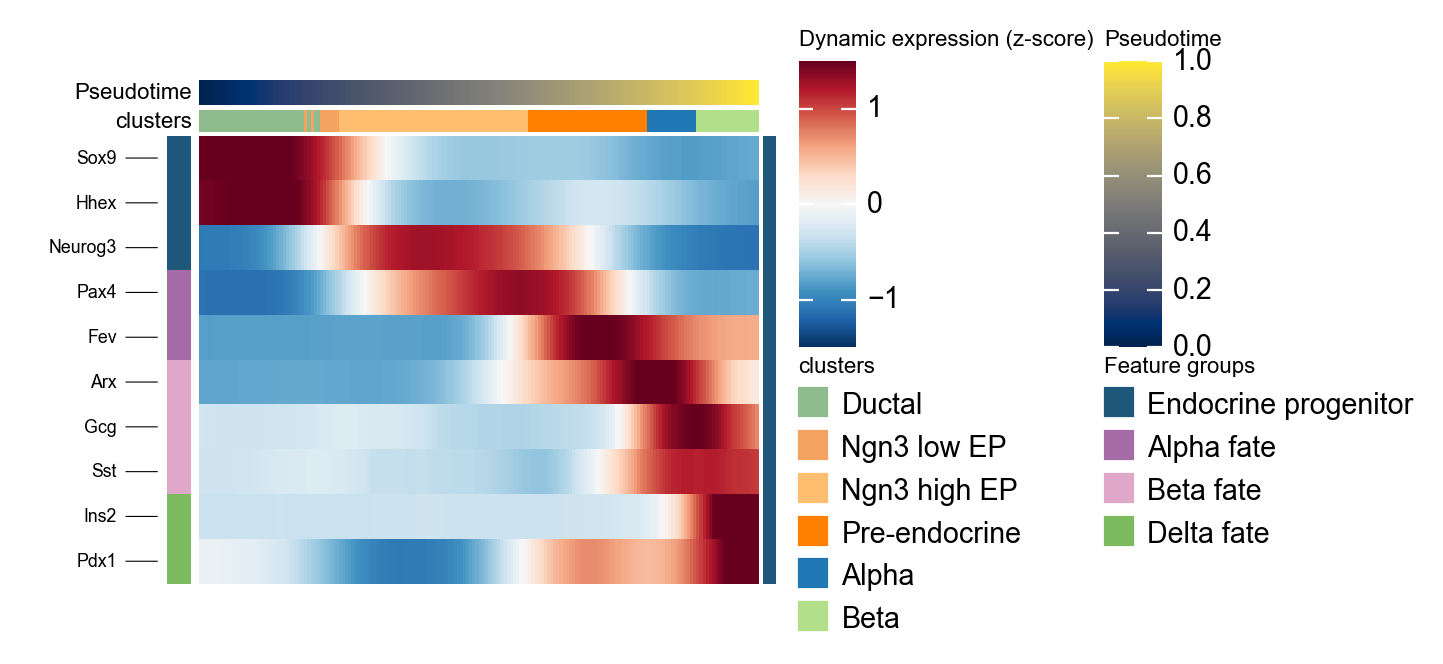

In [19]:
sctour_marker = {
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
}

g = ov.pl.dynamic_heatmap(
    adata,
    var_names=sctour_marker,
    pseudotime='sctour_pseudotime',
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=180,
    smooth_window=17,
    fitted_window=31,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)